# MIMO & Crosstalk Demo

This notebook does three things against the USRP sandbox:

1. **SISO sanity check** — send a single tone, verify the server sends it back.
2. **MIMO transmit** — drive two independent baseband signals onto the two TX channels and look at what each RX antenna captured.
3. **Crosstalk / isolation measurement** — drive a tone on exactly one TX channel at a time and measure how much of it leaks into the other RX channel. Result is the channel-to-channel isolation matrix in dB.

**Requirements:**
- The server must have `MIMO_ENABLED=true` in `.env` (Settings → MIMO).
- Two physical USRP paths (e.g. B210 with TX/RX → RX2, or two B210s).
- The Python package installed: `pip install git+https://github.com/RaresBares/USRP-Benchmark-System.git`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from usrp_benchmark import USRPClient

# ── Server connection ────────────────────────────────────────────────
USRPClient.setup(host="129.132.24.210", port=80,
                 token="rsahleanu-pbmmyfz5ggscdalo4rktbpkl")
info = USRPClient.info()
fs   = int(info["sample_rate_hz"])
fc   = int(info["carrier_frequency_hz"])
bw   = int(info["bandwidth_hz"])
print(f"Server: fc={fc/1e9:.3f} GHz · fs={fs/1e6:.2f} MSps · BW={bw/1e6:.2f} MHz")
print(f"MIMO enabled: {info.get('mimo_enabled', False)}  "
      f"(max channels: {info.get('mimo_max_channels', '?')})")

Server: fc=2.442 GHz · fs=4.00 MSps · BW=2.00 MHz
MIMO enabled: True  (max channels: 2)


## Helper utilities
Generate a tone, plot a spectrum, measure power at a target bin.

In [2]:
def tone(freq_hz, n, fs=fs, amplitude=0.5):
    """Complex-baseband sinusoid at `freq_hz` offset from the carrier."""
    t = np.arange(n) / fs
    return (amplitude * np.exp(2j * np.pi * freq_hz * t)).astype(np.complex64)

def spectrum_db(x, fs=fs):
    """Return (freq_axis_MHz, magnitude_dB) for a complex baseband signal."""
    X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(len(x), d=1/fs)) / 1e6
    mag = 20 * np.log10(np.abs(X) / len(x) + 1e-12)
    return f, mag

def avg_power_db(x):
    """Average IQ power in dBFS (relative to full-scale amplitude 1.0)."""
    return 10 * np.log10(np.mean(np.abs(x)**2) + 1e-20)

def power_in_band_db(x, target_hz, half_bw_hz=50_000, fs=fs):
    """Average power within ±half_bw around `target_hz`, in dBFS."""
    X = np.fft.fftshift(np.fft.fft(x))
    f = np.fft.fftshift(np.fft.fftfreq(len(x), d=1/fs))
    mask = (f >= target_hz - half_bw_hz) & (f <= target_hz + half_bw_hz)
    P = np.sum(np.abs(X[mask])**2) / (len(x) ** 2)
    return 10 * np.log10(P + 1e-20)

## 1. SISO sanity check

Send a 1 MHz tone, look at the round-trip spectrum. If this doesn't work, the rest won't either.

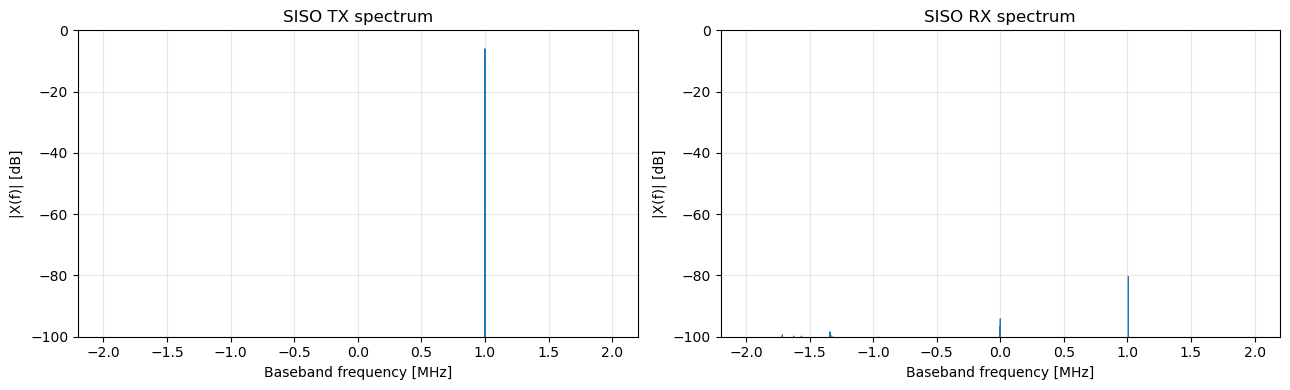

TX avg power: -6.0 dBFS
RX avg power: -58.1 dBFS


In [4]:
N = 50_000
tx_siso = tone(1_000_000, N)          # 1 MHz baseband tone
rx_siso = USRPClient.send(tx_siso)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for sig, label, a in [(tx_siso, "TX", ax[0]), (rx_siso, "RX", ax[1])]:
    f, mag = spectrum_db(sig)
    a.plot(f, mag, lw=0.8)
    a.set_xlabel("Baseband frequency [MHz]")
    a.set_ylabel("|X(f)| [dB]")
    a.set_title(f"SISO {label} spectrum")
    a.grid(True, alpha=0.3)
    a.set_ylim(-100, 0)
plt.tight_layout(); plt.show()

print(f"TX avg power: {avg_power_db(tx_siso):+.1f} dBFS")
print(f"RX avg power: {avg_power_db(rx_siso):+.1f} dBFS")

## 2. MIMO transmit — both channels at once

Drive **two different tones** on the two TX channels simultaneously and look at both RX channels.

Signal layout: `tx_mimo` is a `(N, 2)` array — column 0 is channel 0, column 1 is channel 1.  
Returned `rx_mimo` has the same shape (column = RX channel).

In [5]:
if not info.get("mimo_enabled", False):
    raise RuntimeError(
        "MIMO is disabled on the server. "
        "Set MIMO_ENABLED=true in the admin panel before running this notebook."
    )

F0, F1 = 1_000_000, 2_500_000          # tone per TX channel
tx_mimo = np.stack([tone(F0, N), tone(F1, N)], axis=1)   # (N, 2)
print("TX shape:", tx_mimo.shape)

rx_mimo = USRPClient.send(tx_mimo)
print("RX shape:", rx_mimo.shape)

fig, ax = plt.subplots(2, 2, figsize=(13, 7), sharex=True, sharey=True)
for r, sig in enumerate([tx_mimo, rx_mimo]):
    for c in (0, 1):
        f, mag = spectrum_db(sig[:, c])
        ax[r, c].plot(f, mag, lw=0.8)
        ax[r, c].set_title(f"{'TX' if r==0 else 'RX'} ch {c}")
        ax[r, c].grid(True, alpha=0.3)
        ax[r, c].set_ylim(-110, 0)
for a in ax[-1]:
    a.set_xlabel("Baseband frequency [MHz]")
for a in ax[:, 0]:
    a.set_ylabel("|X(f)| [dB]")
plt.tight_layout(); plt.show()

TX shape: (50000, 2)


RuntimeError: Server error: Traceback (most recent call last):
  File "/app/worker.py", line 74, in poll_and_process
    process_f32(task_uid)
  File "/app/worker.py", line 45, in process_f32
    received = send_and_receive(signal)
               ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/app/channel.py", line 644, in send_and_receive
    return _channel.send_and_receive(signal)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/app/channel.py", line 562, in send_and_receive
    raise RuntimeError(
RuntimeError: RECEIVE_TO_FILE failed: RX stream timeout after receiving 0/250000 samples


## 3. Crosstalk / isolation matrix

For each TX channel `i`, transmit a tone **only** on channel `i` (others silent) and measure the received power around that tone on every RX channel `j`. The isolation in dB is

$$
\mathrm{ISO}_{ij}\; [\mathrm{dB}] \;=\; P_{RX,\,j}(f_i)\;-\;P_{RX,\,i}(f_i)
$$

i.e. how much weaker the leaked signal at channel `j` is compared to the actual transmit channel `i`. The diagonal is therefore always 0 dB by definition. Off-diagonals far below 0 (say −30 dB or lower) = good isolation.

In [39]:
n_ch = int(info.get("mimo_max_channels", 2))
tones_hz = [(i + 1) * 1_500_000 for i in range(n_ch)]   # 1.5, 3.0, 4.5 MHz …
print(f"Probing {n_ch} channels at tones {tones_hz} Hz")

iso = np.full((n_ch, n_ch), np.nan)     # iso[tx, rx]
abs_pow = np.full((n_ch, n_ch), np.nan) # absolute power (dBFS) at f_tx on rx

for tx_ch in range(n_ch):
    tx = np.zeros((N, n_ch), dtype=np.complex64)
    tx[:, tx_ch] = tone(tones_hz[tx_ch], N)
    rx = USRPClient.send(tx)
    f_target = tones_hz[tx_ch]
    p_main = power_in_band_db(rx[:, tx_ch], f_target)
    for rx_ch in range(n_ch):
        p = power_in_band_db(rx[:, rx_ch], f_target)
        abs_pow[tx_ch, rx_ch] = p
        iso[tx_ch, rx_ch] = p - p_main
    print(f"  TX ch {tx_ch} @ {f_target/1e6:.2f} MHz → "
          + "  ".join(f"RX{c}: {abs_pow[tx_ch, c]:+.1f} dBFS" for c in range(n_ch)))

print("\nIsolation matrix (dB, relative to main channel — diagonal is always 0):")
print(np.array2string(iso, formatter={"float": lambda v: f"{v:+6.1f}"}))

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(iso, vmin=-60, vmax=0, cmap="viridis")
for i in range(n_ch):
    for j in range(n_ch):
        ax.text(j, i, f"{iso[i, j]:+.1f}", ha="center", va="center",
                color="white" if iso[i, j] < -20 else "black")
ax.set_xticks(range(n_ch)); ax.set_yticks(range(n_ch))
ax.set_xlabel("RX channel")
ax.set_ylabel("TX channel")
ax.set_title("Crosstalk isolation [dB]\n(more negative off-diagonals = better)")
fig.colorbar(im, ax=ax, label="dB")
plt.tight_layout(); plt.show()

Probing 2 channels at tones [1500000, 3000000] Hz


RuntimeError: Server error: Traceback (most recent call last):
  File "/app/worker.py", line 74, in poll_and_process
    process_f32(task_uid)
  File "/app/worker.py", line 45, in process_f32
    received = send_and_receive(signal)
               ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/app/channel.py", line 591, in send_and_receive
    return _channel.send_and_receive(signal)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/app/channel.py", line 509, in send_and_receive
    raise RuntimeError(
RuntimeError: RECEIVE_TO_FILE failed: RX stream timeout after receiving 0/3122000 samples


## Reading the result

| Off-diagonal value | Interpretation |
|---|---|
| 0 dB | identical — no isolation at all (cable shorted? same antenna?) |
| −10 dB | strong coupling, e.g. two antennas right next to each other |
| −30 dB | typical for B210 internal TX/RX & RX2 ports |
| < −50 dB | excellent isolation, properly separated antennas |

If the diagonal isn't really 0 it means your `power_in_band_db` integration window missed the actual peak (try a wider `half_bw_hz`).

**Caveats on B210:**
- The two RX paths on a single B210 share the same AD9361 chip — true MIMO sees correlated phase noise. Two separate B210s are fully independent but their LOs drift relative to each other (no shared 10 MHz reference).
- On the sandbox config the two B210s are separate devices with independent LOs, so any tone offset is real — phase / frequency drift between the two is expected.
- Crosstalk via the **air** depends entirely on antenna placement; the numbers here mix radio coupling with electrical coupling on the host.